<a href="https://colab.research.google.com/github/nawroz-m/ML_learning/blob/main/Bank_Fraud_Detection_k_means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Tasks to Perform**
1. Apply at least three clustering techniques presented in this course.
2. Learn a Bayesian Network to explore relationships present in the data.
3. Write a report on your findings.
4. Submit a Colab Notebook, a report, a pitch deck.



In [27]:
# import required package
import pandas as pd
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
import seaborn as sns



#Preporcess the dataset
1. Download the dataset & unzip the dataset
2. Read the dataset using pandas
3.

In [2]:
# Download the dataset
!kaggle datasets download valakhorasani/bank-transaction-dataset-for-fraud-detection

Dataset URL: https://www.kaggle.com/datasets/valakhorasani/bank-transaction-dataset-for-fraud-detection
License(s): apache-2.0
100% 102k/102k [00:00<00:00, 32.4MB/s]



In [3]:
# Unzip the dataset
!unzip /content/bank-transaction-dataset-for-fraud-detection.zip

Archive:  /content/bank-transaction-dataset-for-fraud-detection.zip
  inflating: bank_transactions_data_2.csv  


In [109]:
# let's read the dataset csv by pandas
dataset = pd.read_csv('/content/bank_transactions_data_2.csv')
"""
Print the basic dataset infromation
1. How many entries are there in each column
2. How many columns are there
3. The data type  of each coluns
4. Count the null values if exist
5. Memory usage
"""
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance          

As it shows in the dataset information summary there are no columns with null value

In [110]:
# Plot the 5 first head of the dataset
dataset.head(5)

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


In [112]:
"""
Get the unique value of channels, customer occupation and Transaction type
these are important information for detecting the transaction
"""
print(f'Channel unique values: {dataset["Channel"].unique()}')
print(f'Customer Ocupation values: {dataset["CustomerOccupation"].unique()}')
print(f'Transaction Type values: {dataset["TransactionType"].unique()}')

Channel unique values: ['ATM' 'Online' 'Branch']
Customer Ocupation values: ['Doctor' 'Student' 'Retired' 'Engineer']
Transaction Type values: ['Debit' 'Credit']


In [113]:
"""
There are 2 diffirent transaction date for each and every transaction
1. TransactionDate: the date of transaction happend
2. PreviousTransactionDate: the previous transaction date
First we have to find out the days/time between two transactions --> this is
very important in order to find out the gap between each transaction
"""
# to_datetime make sure the date string is proper converted to standard data time
dataset['TransactionDate'] = pd.to_datetime(dataset['TransactionDate'])
dataset['PreviousTransactionDate'] = pd.to_datetime(dataset['PreviousTransactionDate'])

# make sure the time diffirent is in days format
dataset['DaysBetweenTransaction'] = (dataset['TransactionDate'] - dataset['PreviousTransactionDate']).dt.days

# check the DaysBetweenTransaction
dataset.head(5)

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,DaysBetweenTransaction
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08,-573
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35,-496
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04,-483
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06,-549
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39,-385


As it shows the Days between transaction added to the dataset

In [114]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   TransactionID            2512 non-null   object        
 1   AccountID                2512 non-null   object        
 2   TransactionAmount        2512 non-null   float64       
 3   TransactionDate          2512 non-null   datetime64[ns]
 4   TransactionType          2512 non-null   object        
 5   Location                 2512 non-null   object        
 6   DeviceID                 2512 non-null   object        
 7   IP Address               2512 non-null   object        
 8   MerchantID               2512 non-null   object        
 9   Channel                  2512 non-null   object        
 10  CustomerAge              2512 non-null   int64         
 11  CustomerOccupation       2512 non-null   object        
 12  TransactionDuration      2512 non-

In [136]:
# Define number of clustering
K = 3
print(f"The dataset has shape = {dataset.shape}")
print(f"It has {dataset.shape[0]} objects and {dataset.shape[1]} attributes.\n")

# Define a palette of colours for the K clusters
PAL = ['black', 'red', 'green', 'blue', 'yellow', 'orange']

"""
I am only interested in nomerical features
"""
features = dataset[[
    "TransactionAmount",
    "CustomerAge",
    "TransactionDuration",
    "LoginAttempts",
    "AccountBalance",
    "DaysBetweenTransaction"
]]
[N,M] = features.shape # N=Number of object, M=Number of attribute
print(f"The features has shape = {features.shape}")
print(f"It has {N} objects and {M} attributes.")


The dataset has shape = (2512, 17)
It has 2512 objects and 17 attributes.

The features has shape = (2512, 6)
It has 2512 objects and 6 attributes.


In [116]:
"""
Get the statistical summary of nomerical columns(features)
This summary includes key statistical metrics like
[mean, standard deviation, minimum, maximum, different percentiles]
"""
features.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance,DaysBetweenTransaction
count,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000
mean,297.593778,44.673965,119.643312,1.124602,5114.302966,-487.857882
std,291.946243,17.792198,69.963757,0.602662,3900.942499,106.378910
min,0.260000,18.000000,10.000000,1.000000,101.250000,-672.000000
25%,81.885000,27.000000,63.000000,1.000000,1504.370000,-581.000000
50%,211.140000,45.000000,112.500000,1.000000,4735.510000,-486.000000
75%,414.527500,59.000000,161.000000,1.000000,7678.820000,-395.000000
max,1919.110000,80.000000,300.000000,5.000000,14977.990000,-308.000000


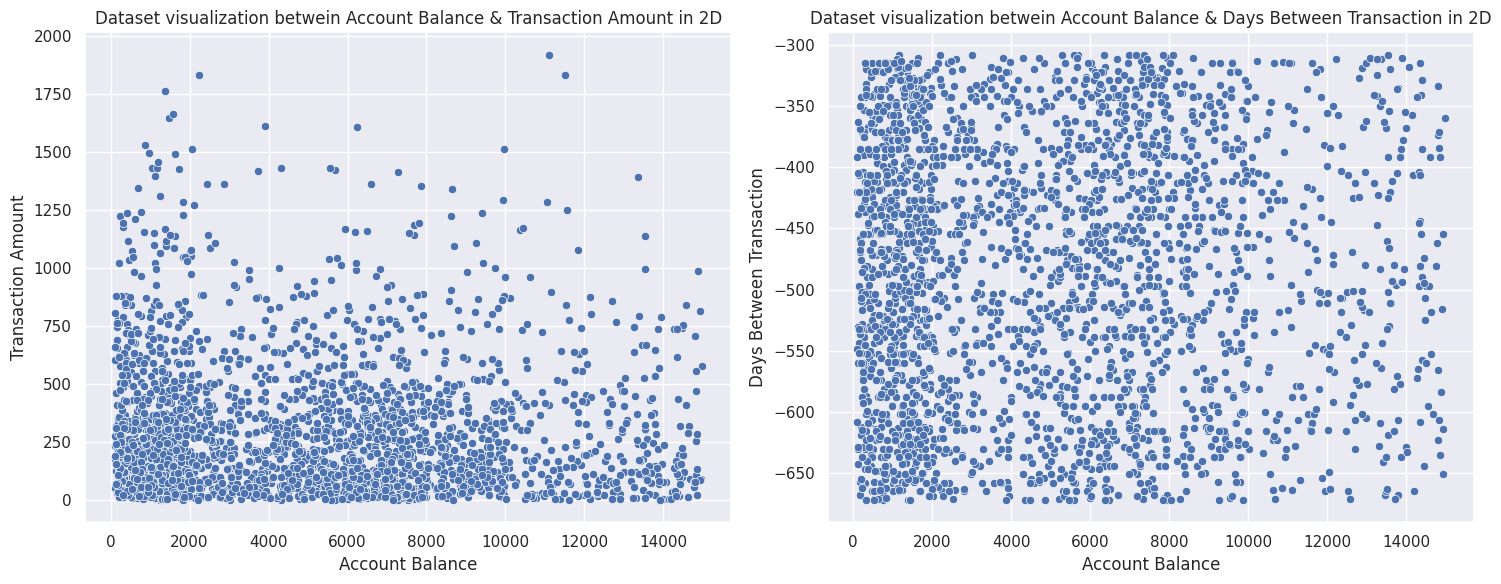

In [118]:
"""
Visualize the Account Balance vs Transaction Amount
and AccountBalance vs DaysBetweenTransaction
"""

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Account Balance vs Transaction Amount
sns.scatterplot( x = features['AccountBalance'], y = features['TransactionAmount'], ax=ax[0])
sns.set_theme(style='dark')
ax[0].set_title('Dataset visualization betwein Account Balance & Transaction Amount in 2D')
ax[0].set_xlabel(f'Account Balance')
ax[0].set_ylabel(f'Transaction Amount')
ax[0].grid()

# Account Balance vs Days Between Transaction
sns.scatterplot( x = features['AccountBalance'], y = features['DaysBetweenTransaction'], ax=ax[1])
sns.set_theme(style='dark')
ax[1].set_title('Dataset visualization betwein Account Balance & Days Between Transaction in 2D')
ax[1].set_xlabel(f'Account Balance')
ax[1].set_ylabel(f'Days Between Transaction')
ax[1].grid()
plt.tight_layout()


In [185]:
"""
Let's visualize the PCA & tSNE
"""
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def PCA_tSNE_visualization(data_2d, n_components, labels, PAL, CENTROIDS=None, SSE=None):
  """
  INPUT
  data_2d --> a 2D data matrix to visualize
  n_components ---> no. of components to decompose the dataset during PCA
  labels ---> labels given by the clustering
  PAL ---> palette of colours to distinguish between clusters
  """

  '''
  OUTPUT
  Two figures ---> one using PCA and one using tSNE
  '''


  # get the PCA
  pca = PCA(n_components=n_components)
  pca_result = pca.fit_transform(data_2d)
  print('PCA explained variance: ', pca.explained_variance_ratio_.round(2))

  # transform centroids INTO PCA SPACE
  if CENTROIDS is not None:
      centroids_pca = pca.transform(CENTROIDS)

  # get the tSNE
  tsne = TSNE(n_components=n_components, verbose=0, perplexity=20, max_iter=300)
  tsne_results = tsne.fit_transform(data_2d)

  # Plots
  fig, ax = plt.subplots(1, 2, figsize=(15, 6))
  fig.suptitle(f'SSE {SSE}')


  # Plot 1: PCA features
  sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1], ax=ax[0], hue=labels, palette=PAL)

  ax[0].set_xlabel('Dimension 1', fontsize=10)
  ax[0].set_ylabel('Dimension 2', fontsize=10)

  # plot centroids if provided
  if CENTROIDS is not None:
    for i in range(centroids_pca.shape[0]):
      ax[0].scatter(
          centroids_pca[i, 0],
          centroids_pca[i, 1],
          s=250,
          color=PAL[i],
          marker='X',
          edgecolor='black',
          label=f'Centroid {i}'
      )

  ax[0].set_title("PCA")
  ax[0].legend()
  ax[0].grid()

  # Plot 1: TSNE features
  sns.scatterplot(x=tsne_results[:,0], y=tsne_results[:,1], ax=ax[1], hue=labels, palette=PAL)
  ax[1].set_xlabel('Dimension 1', fontsize=10)
  ax[1].set_ylabel('Dimension 2', fontsize=10)
  ax[1].title.set_text('tSNE')
  ax[1].grid()
plt.tight_layout()

<Figure size 640x480 with 0 Axes>

In [142]:
"""
Let's calculate the k-menas of the features
"""
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=K, init='random', n_init=1, max_iter=300, tol=0.0001, verbose=1, random_state=42).fit(features)

# Print the final minimized Sume of Squared Error(SSE)
print(f'\nThe final SSE is: {kmeans.inertia_} ')

# get the k-means labels
features_lables = kmeans.labels_
# get the centroid for each clusters
centroids = kmeans.cluster_centers_

Initialization complete
Iteration 0, inertia 12895888818.63853.
Iteration 1, inertia 4601372333.00921.
Iteration 2, inertia 4536224756.60385.
Iteration 3, inertia 4524413852.327415.
Iteration 4, inertia 4520062697.814998.
Iteration 5, inertia 4518872235.070151.
Iteration 6, inertia 4518093566.053333.
Iteration 7, inertia 4517570119.636016.
Iteration 8, inertia 4517213302.893801.
Converged at iteration 8: center shift 173.16453727440933 within tolerance 255.21691565876526.

The final SSE is: 4517027529.720414 


PCA explained variance:  [0.99 0.01]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/tmp/ipykernel_1052/4111309293.py:41: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1], ax=ax[0], hue=labels, palette=PAL)
/tmp/ipykernel_1052/4111309293.py:64: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.scatterplot(x=tsne_results[:,0], y=tsne_results[:,1], ax=ax[1], hue=labels, palette=PAL)


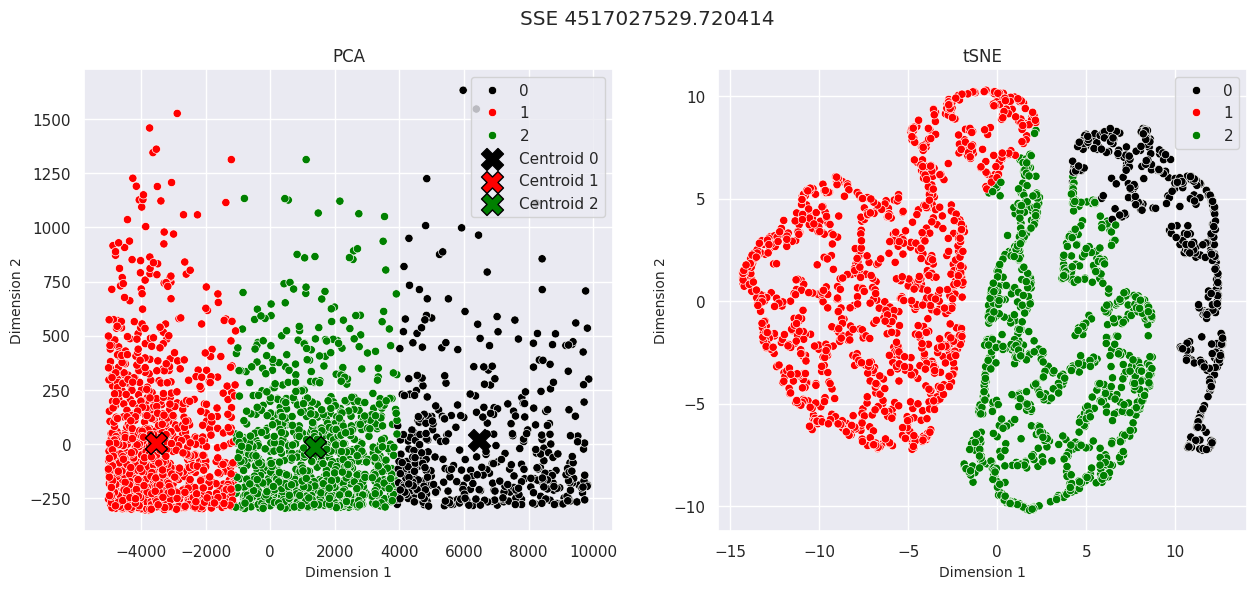

In [186]:
"""
Plot the PCA and tSNE of features without scalling
"""
DIMENSIONS = 2
PCA_tSNE_visualization(features, DIMENSIONS, features_lables, PAL, centroids, kmeans.inertia_)


Meaning:
* The principal component explains 99% of the variance
* Second explains 1%

So the data is almost lying along ONE dominant direction.

This usually happens because:

* *one feature dominates the dataset*
* features are highly correlated
* scaling was not applied correctly

**In order to overcome the *feature dominants* it's better to scale individual variable based on their distribution (column by column)**

In [177]:
from sklearn.preprocessing import StandardScaler

"""
Scale all important nomerical columns
"""
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [183]:
"""
Let's calculate the k-menas of the scaled features
"""

scaled_kmeans = KMeans(n_clusters=K, init='random', n_init=1, max_iter=300, tol=0.0001, verbose=1, random_state=42).fit(scaled_features)

# Print the final minimized Sume of Squared Error(SSE)
print(f'\nThe final SSE without scaled is: {kmeans.inertia_} ')
print(f'The final SSE with scaled is: {scaled_kmeans.inertia_} ')

# get the k-means labels
scaled_features_lables = scaled_kmeans.labels_
# get the centroid for each clusters
scaled_centroids = scaled_kmeans.cluster_centers_
print(f'Labels after scaled: {np.unique(scaled_features_lables)}')

Initialization complete
Iteration 0, inertia 15085.310687953492.
Iteration 1, inertia 11768.534076733013.
Iteration 2, inertia 11650.631554681915.
Iteration 3, inertia 11588.08644485969.
Iteration 4, inertia 11560.356579069381.
Iteration 5, inertia 11539.642203127209.
Iteration 6, inertia 11523.984224284046.
Iteration 7, inertia 11516.936047038267.
Iteration 8, inertia 11507.952281228254.
Iteration 9, inertia 11495.526650274269.
Iteration 10, inertia 11478.748576054857.
Iteration 11, inertia 11452.363917478076.
Iteration 12, inertia 11418.010058267784.
Iteration 13, inertia 11381.276640377013.
Iteration 14, inertia 11364.457483382308.
Iteration 15, inertia 11358.048991251098.
Iteration 16, inertia 11355.315308666777.
Iteration 17, inertia 11353.963945748354.
Iteration 18, inertia 11353.236971657485.
Iteration 19, inertia 11352.14149211703.
Iteration 20, inertia 11351.707813661413.
Iteration 21, inertia 11351.491230848587.
Converged at iteration 21: center shift 3.3463125278206376e-05 w

As it shows the Final **SSE** for after scaled is also reduce a lot

Which measures:
* How far points are from their cluster centroids
* Lower SSE means better compact clusters

PCA explained variance:  [0.22 0.17]


/tmp/ipykernel_1052/4111309293.py:41: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1], ax=ax[0], hue=labels, palette=PAL)
/tmp/ipykernel_1052/4111309293.py:64: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.scatterplot(x=tsne_results[:,0], y=tsne_results[:,1], ax=ax[1], hue=labels, palette=PAL)


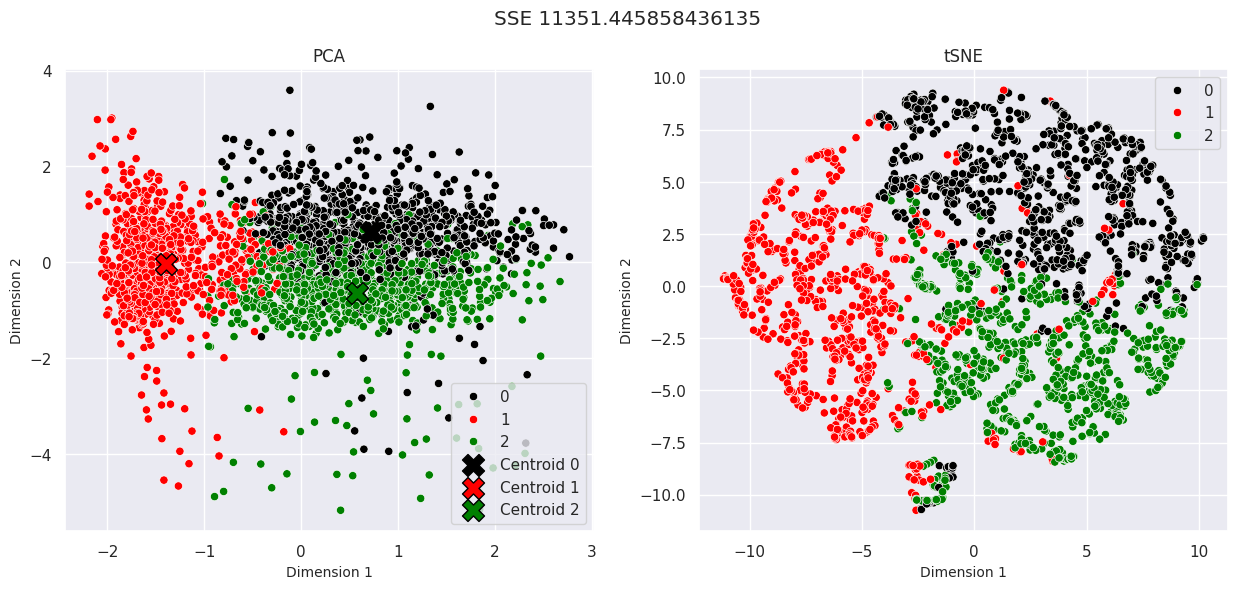

In [187]:
"""
Plot the PCA and tSNE of scaled features
"""
PCA_tSNE_visualization(scaled_features, DIMENSIONS, scaled_features_lables, PAL, scaled_centroids, scaled_kmeans.inertia_)

Now I have:

* PC1 explains 22% of variance
* PC2 explains 17% of variance

Which means my data
* is **NOT dominated** by one feature anymore
* is more **balanced** across features
* has more **complex structure**